0. # Fully-Connected Feed-Forward Neural Network para trabajar con CIFAR-10

## 1. Dataset CIFAR-10 y tarea asociada

**CIFAR-10** es un conjunto de datos de clasificación de imágenes a color compuesto por **60,000** imágenes pequeñas de tamaño **32×32** píxeles, con **3 canales (RGB)** y **10 clases**. Se divide típicamente en:

- **50,000** imágenes para entrenamiento
- **10,000** imágenes para prueba (test)

### Clases
1. airplane
2. automobile
3. bird
4. cat
5. deer
6. dog
7. frog
8. horse
9. ship
10. truck

### Tarea asociada al conjunto de datos
Dada una imagen RGB de 32×32, el modelo debe predecir su **etiqueta de clase** (clasificación multiclase).


## 2. Objetivo de la práctica

El objetivo es **probar el desempeño de redes Fully-Connected Feed-Forward (MLP)** en un conjunto de datos **“pesado”** para redes totalmente conectadas y con **características espaciales** claras.

### ¿Por qué CIFAR-10 es desafiante para un MLP?

Un MLP requiere **aplanar** la imagen, convirtiendo una matriz 32×32×3 en un vector de **3072** características. Al hacerlo:

- Se **pierde la estructura espacial** (vecindades y patrones locales).
- El MLP no tiene mecanismos explícitos de **invariancia a traslación** (el mismo objeto en distinta posición se ve “diferente” para el vector).
- Para modelar relaciones espaciales, el MLP tiende a necesitar **muchos parámetros** y aun así generaliza peor.



In [20]:
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np



## 3. Obtener CIFAR-10 desde PyTorch

En PyTorch, CIFAR-10 está disponible en `torchvision.datasets.CIFAR10`.  
En esta sección descargaremos el dataset y definiremos transformaciones básicas.


In [21]:
# Transformación: convertir a tensor (C,H,W) y normalizar
# Valores típicos de normalización para CIFAR-10 (por canal RGB)
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std  = (0.2470, 0.2435, 0.2616)
# jajaja que onda con esto de donde salen esos numeros y por que

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(cifar10_mean, cifar10_std)
])
# esto es como una especie de pipline de lo que se le hara a los datos para transformarlos?



train_full = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

class_names = train_full.classes
len(train_full), len(test_set), class_names


(50000,
 10000,
 ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'])

## 4. Visualización: matriz de imágenes (2 por clase)

A continuación se muestra una cuadrícula de **2 imágenes por clase** (20 imágenes).  
Esto permite observar variedad, ruido y la naturaleza espacial/visual de los patrones.


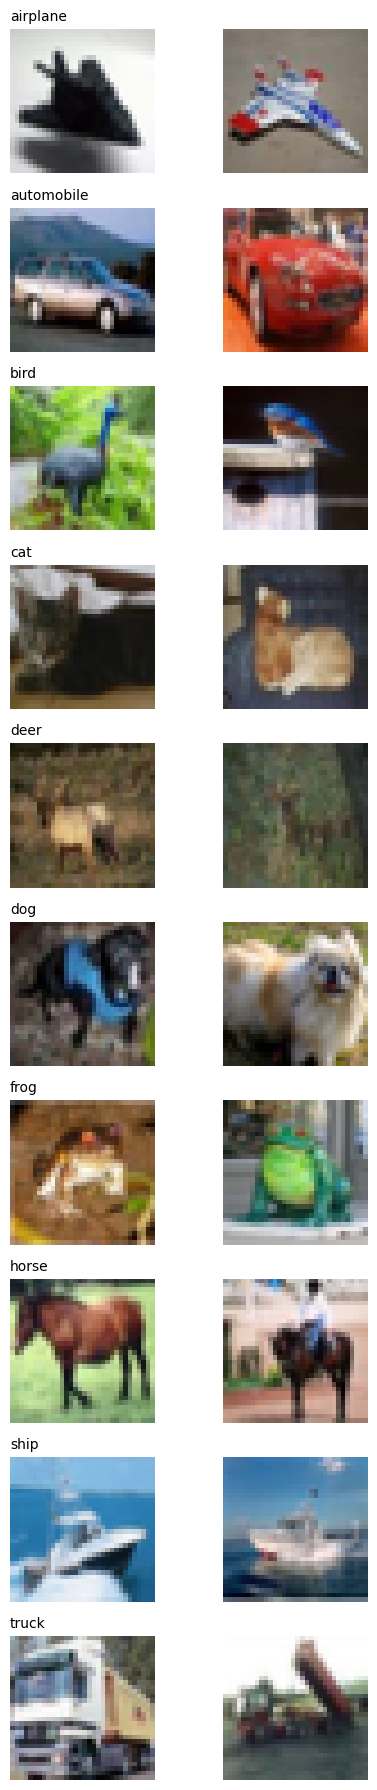

In [22]:
# Utilidad para des-normalizar (solo para mostrar imágenes correctamente)
mean = torch.tensor(cifar10_mean).view(3,1,1)
std  = torch.tensor(cifar10_std).view(3,1,1)
#

def denormalize(img_tensor):
    return (img_tensor * std + mean).clamp(0, 1)

# Tomar 2 ejemplos por clase
examples = {c: [] for c in range(10)}

for img, label in train_full:
    if len(examples[label]) < 2:
        examples[label].append(img)
    if all(len(examples[c]) == 2 for c in range(10)):
        break

# Plot: 10 filas (clases) x 2 columnas (ejemplos)
fig, axes = plt.subplots(10, 2, figsize=(5, 18))
for c in range(10):
    for j in range(2):
        ax = axes[c, j]
        img = denormalize(examples[c][j])
        ax.imshow(img.permute(1,2,0))
        ax.axis("off")
        if j == 0:
            ax.set_title(class_names[c], loc="left", fontsize=10)

plt.tight_layout()
plt.show()


## 5. Preprocesamiento para MLP: aplanar (flatten) los tensores

Un MLP (Fully-Connected) espera vectores, no tensores 3D (C×H×W).  
Por lo tanto, convertiremos cada imagen de forma:

- **Entrada original:** `x ∈ ℝ^{3×32×32}`
- **Entrada al MLP:** `x_flat ∈ ℝ^{3072}`

Esto se logra usando `torch.flatten(x, start_dim=0)` (para un solo ejemplo) o `torch.flatten(x, start_dim=1)` (para un batch).


In [23]:
# Ejemplo: ver forma original y forma aplanada (un ejemplo)
x0, y0 = train_full[0]
print("Forma original (C,H,W):", x0.shape)
x0_flat = torch.flatten(x0)  # start_dim=0 por default
print("Forma aplanada:", x0_flat.shape)


Forma original (C,H,W): torch.Size([3, 32, 32])
Forma aplanada: torch.Size([3072])


### ¿Cómo se aplica el flatten en el entrenamiento?

Cuando el DataLoader entrega un batch, la forma de `x` es:

`(batch_size, 3, 32, 32)`

Para pasarlo a un MLP se usa:

`x = torch.flatten(x, start_dim=1)`

Eso produce:

`(batch_size, 3072)`


## 6. Construir conjuntos de entrenamiento y validación 
Del conjunto de entrenamiento de CIFAR-10 (50,000 imágenes), separaremos:

- **90%** para entrenamiento
- **10%** para validación

El conjunto de prueba (test) se mantiene **intacto** para evaluación final.


In [24]:
val_fraction = 0.10
n_total = len(train_full)         # 50,000
n_val = int(n_total * val_fraction)
n_train = n_total - n_val

train_set, val_set = random_split(
    train_full, [n_train, n_val]
)

print("Entrenamiento:", len(train_set))
print("Validación:", len(val_set))
print("Prueba:", len(test_set))


Entrenamiento: 45000
Validación: 5000
Prueba: 10000


In [25]:
# DataLoaders
BATCH_SIZE = 256

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Ver un batch y aplicar flatten (demostración)
xb, yb = next(iter(train_loader))
print("Batch original:", xb.shape)
xb_flat = torch.flatten(xb, start_dim=1)
print("Batch flat:", xb_flat.shape)


Batch original: torch.Size([256, 3, 32, 32])
Batch flat: torch.Size([256, 3072])


## 7. Actividad: entrenar 5 configuraciones distintas de MLP

**Instrucciones:** Implementa y entrena **5 redes Fully-Connected Feed-Forward** (MLP) con diferentes topologías.  
En todos los casos:

1. La entrada debe ser el vector **flat de 3072** valores.
2. La salida debe ser una capa final de tamaño **10** (una neurona por clase), usando **softmax implícito** vía `CrossEntropyLoss`.
3. Para cada configuración debes:
   - Entrenar el modelo.
   - Mostrar la **gráfica de convergencia** del entrenamiento (*loss vs época*).
   - Guardar y reportar al final:   
     - **Error (loss) y exactitud (accuracy) en entrenamiento**
     - **Error (loss) y exactitud (accuracy) en prueba (test)**

### Hiperparámetros sugeridos (misma base para las 5 redes)
- **Épocas:** 30 
- **Batch size:** 256
- **Optimizador:** AdamW
- **Learning rate:** 1e-3
- **Weight decay:** 1e-4
- **Función de pérdida:** CrossEntropyLoss
- **Activación:** ReLU


---

## 7.1 Configuraciones obligatorias (5 redes)

### Red 1 — MLP pequeño (baseline)
- Capas ocultas: **1**
- Neuronas: **[256]**

### Red 2 — MLP mediano
- Capas ocultas: **2**
- Neuronas: **[512, 256]**

### Red 3 — MLP profundo (más capacidad)
- Capas ocultas: **3**
- Neuronas: **[1024, 512, 256]**

### Red 4 — MLP muy profundo (mayor profundidad)
- Capas ocultas: **5**
- Neuronas: **[1024, 1024, 512, 512, 256]**

### Red 5 — MLP ancho (más neuronas, menos profundidad)
- Capas ocultas: **2**
- Neuronas: **[2048, 1024]**

---

## 7.2 Qué entregar

1. Una tabla resumen con 5 filas (una por red) y columnas:
   - Topología (capas/neurona)
   - # parámetros
   - Accuracy train
   - Loss train
   - Accuracy test
   - Loss test

2. Las 5 gráficas de convergencia (una por red).

3. Una presentación con de desarrollo:
   - Introducción
   - Descripción del dataset
   - Descripción general de las redes a usar
   - Conguración experimental
   - Resultados
   Deseable, analizar y responder:
      - ¿Qué configuración generaliza mejor?
      - ¿Qué señales de sobreajuste observaste?
      - ¿Qué limitaciones del MLP identificas al trabajar con imágenes?

NOTA: Proponer una 6ta arquitectura procurando mejorar el rendimiento obtenido con respecto a las 5 arquitecturas definidas inicialmente. Se debe justificar la elección de la arquitectura y criterio de la propuesta. Las demás especificaciones deben continuar igual

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_SIZE = 3072
OUTPUT_SIZE = 10
EPOCHS = 30
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

In [27]:
class MLP(nn.Module):
    def __init__(self, layer_sizes):
        super(MLP, self).__init__()
        layers = []
        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < len(layer_sizes) - 2:
                layers.append(nn.ReLU())
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [28]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.flatten(start_dim=1).to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.flatten(start_dim=1).to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    return running_loss / total, correct / total

In [29]:
configs = {
     # "Red 0 (Prueba)" : [INPUT_SIZE, 32, 32, OUTPUT_SIZE],
     "Red 1 (Baseline)": [INPUT_SIZE, 256, OUTPUT_SIZE],
     "Red 2 (Mediano)": [INPUT_SIZE, 512, 256, OUTPUT_SIZE],
     "Red 3 (Profundo)": [INPUT_SIZE, 1024, 512, 256, OUTPUT_SIZE],
     "Red 4 (Muy Profundo)": [INPUT_SIZE, 1024, 1024, 512, 512, 256, OUTPUT_SIZE],
     "Red 5 (Ancho)": [INPUT_SIZE, 2048, 1024, OUTPUT_SIZE]
}

In [30]:
results = []
histories = {}

print(f"Dispositivo de entrenamiento: {device}")

for name, topology in configs.items():
    print(f"\nEntrenando: {name} | Topología: {topology}")
    
    model = MLP(topology).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    train_loss_history = []
    val_loss_history = []
    
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoca {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")
            
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    num_params = sum(p.numel() for p in model.parameters())
    
    histories[name] = {
        "train": train_loss_history,
        "val": val_loss_history
    }
    
    results.append({
        "Arquitectura": name,
        "Topología": str(topology[1:-1]),
        "Parámetros": num_params,
        "Train Loss": train_loss_history[-1],
        "Train Acc": train_acc,
        "Test Loss": test_loss,
        "Test Acc": test_acc
    })

Dispositivo de entrenamiento: cuda

Entrenando: Red 1 (Baseline) | Topología: [3072, 256, 10]
Epoca 5/30 - Train Loss: 1.2234 - Val Loss: 1.4503 - Val Acc: 0.5078
Epoca 10/30 - Train Loss: 0.9896 - Val Loss: 1.5546 - Val Acc: 0.5050
Epoca 15/30 - Train Loss: 0.8064 - Val Loss: 1.5927 - Val Acc: 0.5208
Epoca 20/30 - Train Loss: 0.6317 - Val Loss: 1.7707 - Val Acc: 0.5160
Epoca 25/30 - Train Loss: 0.5143 - Val Loss: 1.9471 - Val Acc: 0.5208
Epoca 30/30 - Train Loss: 0.4266 - Val Loss: 2.1896 - Val Acc: 0.5218

Entrenando: Red 2 (Mediano) | Topología: [3072, 512, 256, 10]
Epoca 5/30 - Train Loss: 1.1332 - Val Loss: 1.3887 - Val Acc: 0.5234
Epoca 10/30 - Train Loss: 0.7575 - Val Loss: 1.5485 - Val Acc: 0.5332
Epoca 15/30 - Train Loss: 0.4608 - Val Loss: 1.9630 - Val Acc: 0.5310
Epoca 20/30 - Train Loss: 0.2904 - Val Loss: 2.4673 - Val Acc: 0.5282
Epoca 25/30 - Train Loss: 0.2197 - Val Loss: 2.8737 - Val Acc: 0.5136
Epoca 30/30 - Train Loss: 0.1634 - Val Loss: 3.2856 - Val Acc: 0.5344

Entr

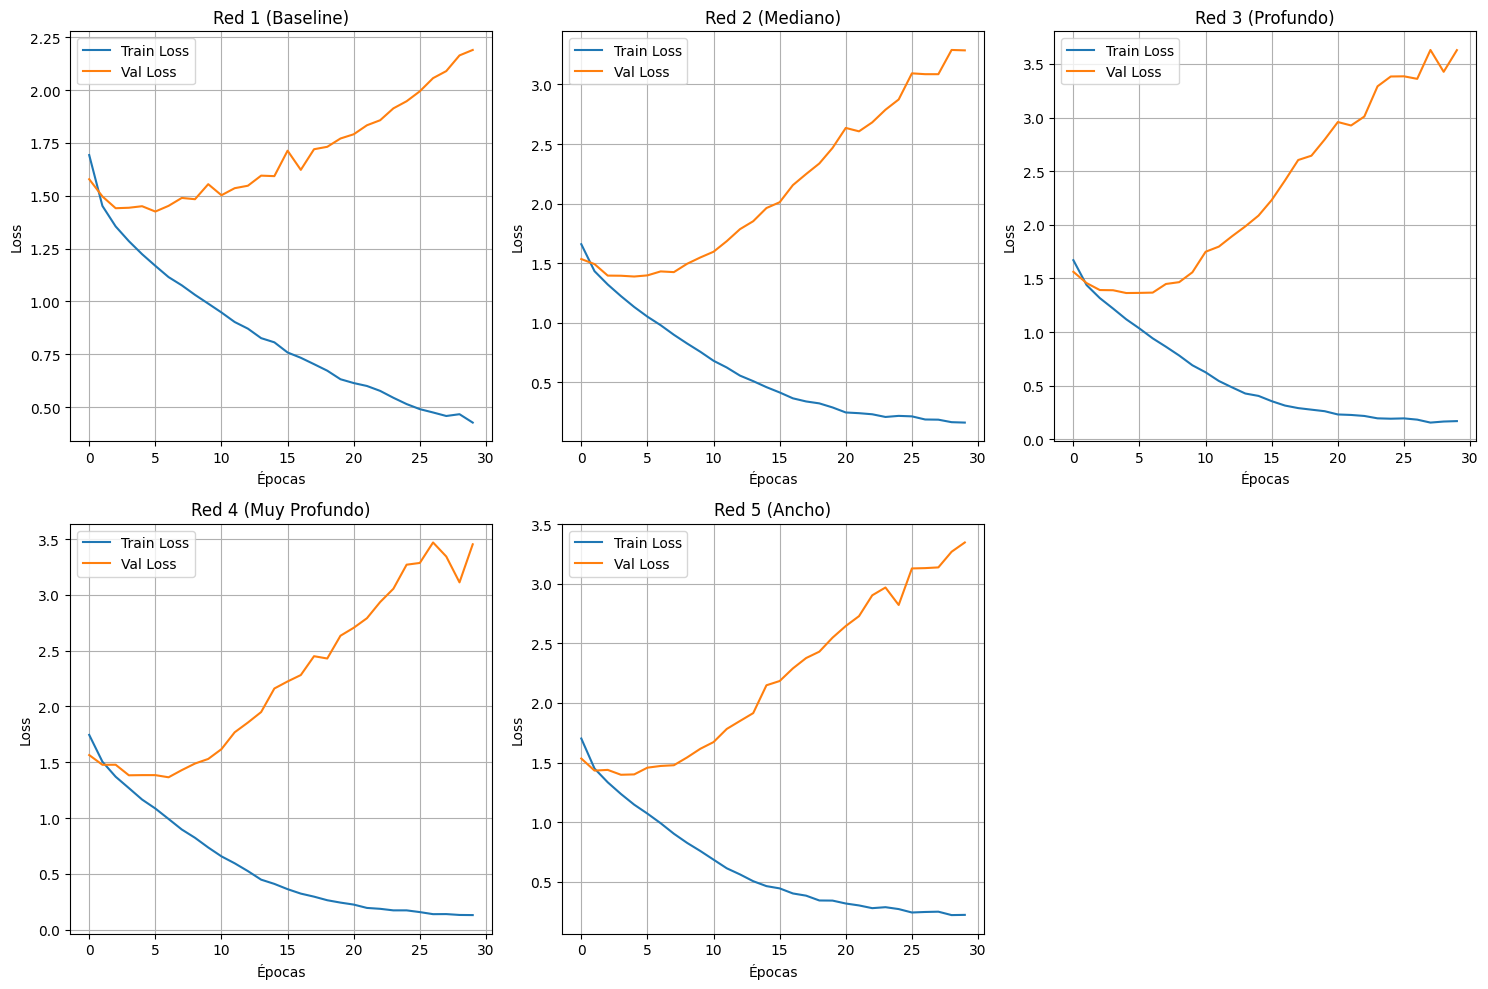


RESUMEN DE RESULTADOS:


,Arquitectura,Topología,Parámetros,Train Loss,Train Acc,Test Loss,Test Acc
0,Red 1 (Baseline),[256],789258,0.426596,0.856756,2.196466,0.5108
1,Red 2 (Mediano),"[512, 256]",1707274,0.163414,0.944800,3.343608,0.5244
2,Red 3 (Profundo),"[1024, 512, 256]",3805450,0.170543,0.942911,3.703824,0.5225
3,Red 4 (Muy Profundo),"[1024, 1024, 512, 512, 256]",5117706,0.130100,0.956044,3.435562,0.5413
4,Red 5 (Ancho),"[2048, 1024]",8401930,0.221764,0.922733,3.344596,0.5331


In [31]:
plt.figure(figsize=(15, 10))

for i, (name, history) in enumerate(histories.items()):
    plt.subplot(2, 3, i + 1)
    plt.plot(history['train'], label='Train Loss')
    plt.plot(history['val'], label='Val Loss')
    plt.title(name)
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

df_results = pd.DataFrame(results)
print("\nRESUMEN DE RESULTADOS:")
display(df_results)

# PROPUESTA:

In [32]:
def train_epoch(model, loader, criterion, optimizer, device, l2_lambda=0.001):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.flatten(start_dim=1).to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        l2_reg = torch.tensor(0., device=device)
        for param in model.parameters():
            l2_reg += torch.norm(param, 2)**2
            
        loss = loss + l2_lambda * l2_reg
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    return running_loss / total, correct / total


Entrenando: Red 6 (Optimizada)
Epoca 5/30 - Train Loss: 1.6008 - Val Loss: 1.4288 - Val Acc: 0.4922
Epoca 10/30 - Train Loss: 1.4939 - Val Loss: 1.3728 - Val Acc: 0.5244
Epoca 15/30 - Train Loss: 1.4391 - Val Loss: 1.3395 - Val Acc: 0.5300
Epoca 20/30 - Train Loss: 1.3977 - Val Loss: 1.3222 - Val Acc: 0.5308
Epoca 25/30 - Train Loss: 1.3714 - Val Loss: 1.3587 - Val Acc: 0.5390
Epoca 30/30 - Train Loss: 1.3521 - Val Loss: 1.3384 - Val Acc: 0.5450


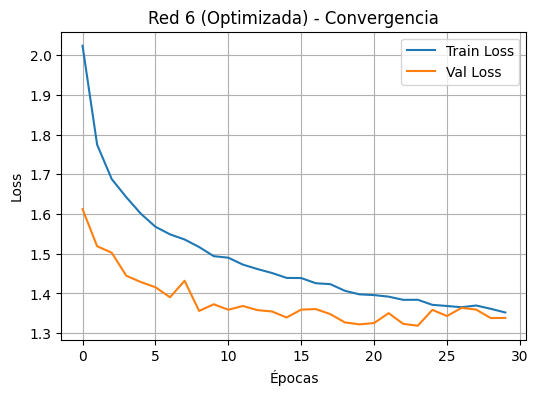


TABLA FINAL COMPARATIVA:


,Arquitectura,Topología,Parámetros,Train Loss,Train Acc,Test Loss,Test Acc
0,Red 1 (Baseline),[256],789258,0.426596,0.856756,2.196466,0.5108
1,Red 2 (Mediano),"[512, 256]",1707274,0.163414,0.944800,3.343608,0.5244
2,Red 3 (Profundo),"[1024, 512, 256]",3805450,0.170543,0.942911,3.703824,0.5225
3,Red 4 (Muy Profundo),"[1024, 1024, 512, 512, 256]",5117706,0.130100,0.956044,3.435562,0.5413
4,Red 5 (Ancho),"[2048, 1024]",8401930,0.221764,0.922733,3.344596,0.5331
5,Red 6 (Optimizada),"[1024, 512, 256] + BN + Drop",3809034,1.573330,0.545044,1.310162,0.5359
6,Red 6 (Optimizada),"[1024, 512, 256] + BN + Drop",3809034,1.573507,0.547333,1.305308,0.5345
7,Red 6 (Optimizada),"[1024, 512, 256] + BN + Drop",3809034,1.618406,0.522822,1.323003,0.5351
8,Red 6 (Optimizada),"[1024, 512, 256] + BN + Drop",3809034,1.232091,0.679267,1.355229,0.5339
9,Red 6 (Optimizada),"[1024, 512, 256] + BN + Drop",3805450,1.352099,0.640800,1.347742,0.5425


In [ ]:
class OptimizedMLP(nn.Module):
    def __init__(self, input_size=3072, output_size=10):
        super(OptimizedMLP, self).__init__()
        
        self.model = nn.Sequential(
            
            nn.Linear(input_size, 1024),
       
            nn.ReLU(),               
            
            nn.Linear(1024, 512),
            nn.ReLU(),

            
            nn.Linear(512, 256),
            nn.ReLU(),
        
            
            nn.Linear(256, output_size)
        )

    def forward(self, x):
        return self.model(x)

print(f"\nEntrenando: Red 6 (Optimizada)")

model_opt = OptimizedMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_opt.parameters(), lr=1e-3, weight_decay=1e-4)

train_loss_hist_opt = []
val_loss_hist_opt = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model_opt, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model_opt, val_loader, criterion, device)
    
    train_loss_hist_opt.append(train_loss)
    val_loss_hist_opt.append(val_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoca {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

test_loss, test_acc = evaluate(model_opt, test_loader, criterion, device)
num_params = sum(p.numel() for p in model_opt.parameters())

results.append({
    "Arquitectura": "Red 6 (Optimizada)",
    "Topología": "[1024, 512, 256] + L2 Explicito",
    "Parámetros": num_params,
    "Train Loss": train_loss_hist_opt[-1],
    "Train Acc": train_acc,
    "Test Loss": test_loss,
    "Test Acc": test_acc
})

plt.figure(figsize=(6, 4))
plt.plot(train_loss_hist_opt, label='Train Loss')
plt.plot(val_loss_hist_opt, label='Val Loss')
plt.title("Red 6 (Optimizada) - Convergencia")
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

df_final = pd.DataFrame(results)
print("\nTABLA FINAL COMPARATIVA:")
display(df_final)